In [1]:
!pip install tensorflow openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os

In [7]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [8]:
data_folder   = r"/content"
output_folder = r"/content"

os.makedirs(output_folder, exist_ok=True)

files = glob.glob(os.path.join(data_folder, "RevenueCenter_*.xlsx"))

In [9]:
# Error matrix
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

In [10]:
def create_sequences(series, window=30):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)


Processing: RevenueCenter_5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0943 - val_loss: 0.2580
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0464 - val_loss: 0.1712
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0211 - val_loss: 0.0556
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0097 - val_loss: 0.0565
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0116 - val_loss: 0.0682
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0134 - val_loss: 0.0575
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0094 - val_loss: 0.0447
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0070 - val_loss: 0.0319
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0087 - val_loss: 0.0184
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0064 - val_loss: 0.0248
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0054 - val_loss: 0.0193
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step

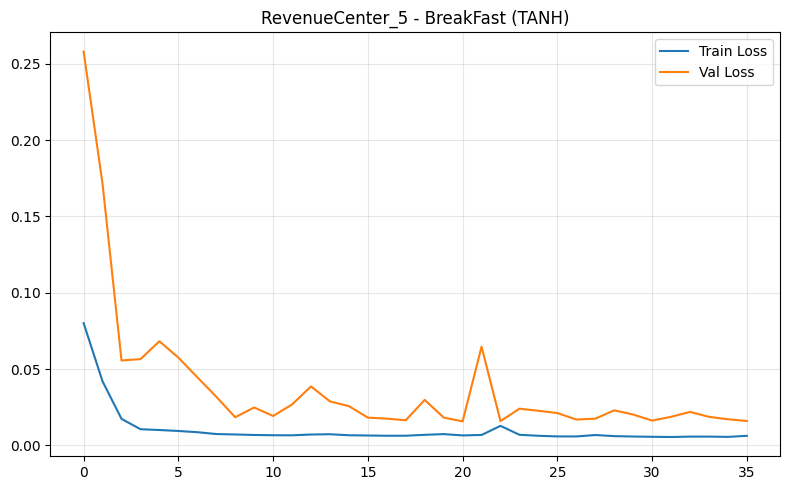

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


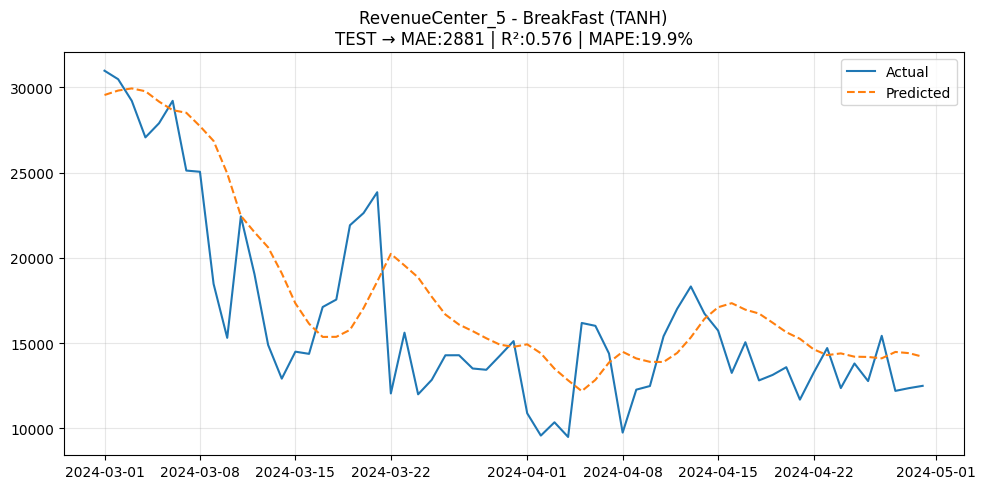

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0165 - val_loss: 0.0204
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0153 - val_loss: 0.0216
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0192 - val_loss: 0.0209
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0152 - val_loss: 0.0184
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.0155 - val_loss: 0.0159
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.0123 - val_loss: 0.0177
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0167 - val_loss: 0.0199
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0162 - val_loss: 0.0177
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0151 - val_loss: 0.0188
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0139 - val_loss: 0.0180
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0125 - val_loss: 0.0164
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step

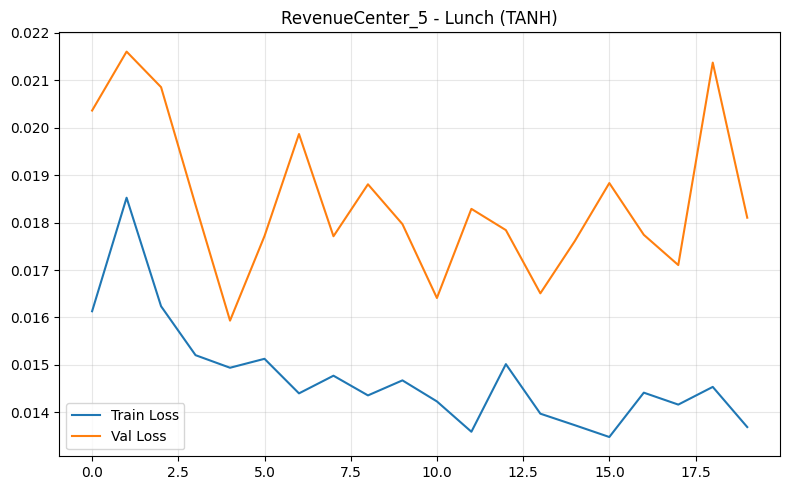

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


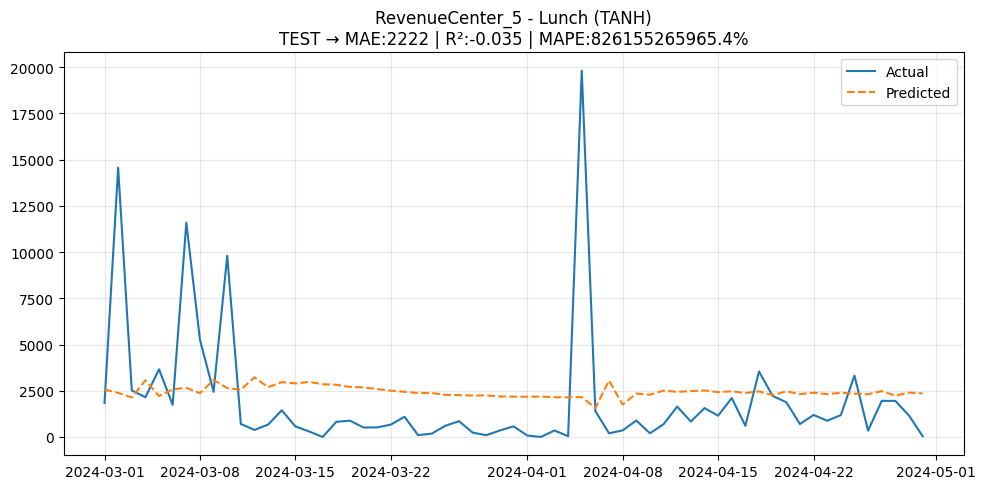

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0392 - val_loss: 0.0622
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0283 - val_loss: 0.0518
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0218 - val_loss: 0.0580
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0231 - val_loss: 0.0545
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0235 - val_loss: 0.0593
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0197 - val_loss: 0.0617
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0199 - val_loss: 0.0574
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0189 - val_loss: 0.0593
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0203 - val_loss: 0.0590
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0204 - val_loss: 0.0574
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0186 - val_loss: 0.0628
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step

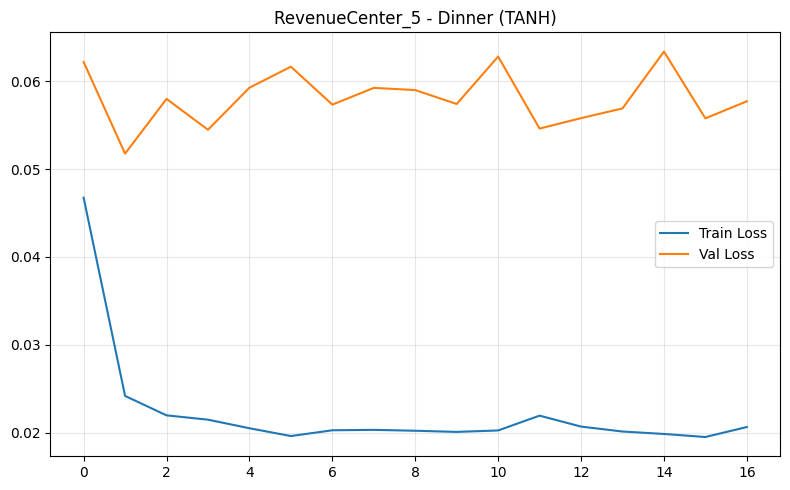

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


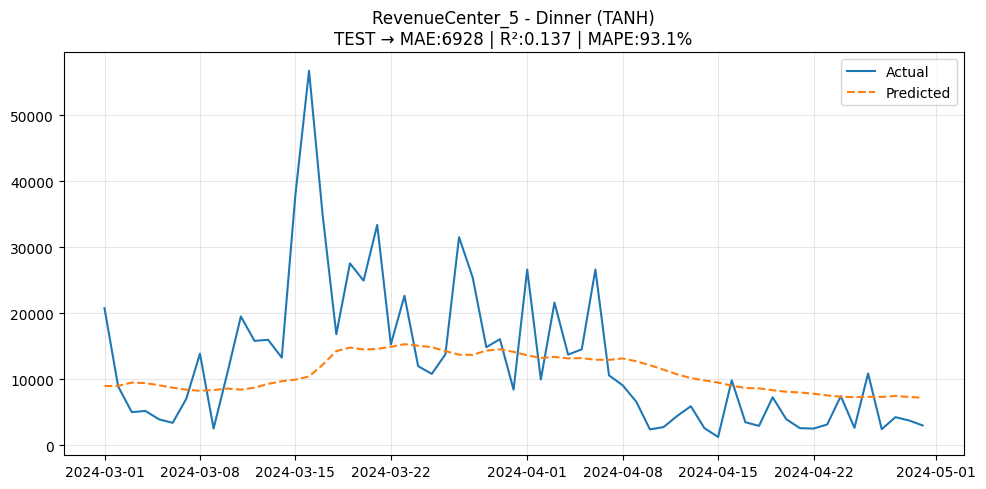

Saved: /content/RevenueCenter_5

Processing: RevenueCenter_7


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0108 - val_loss: 0.0049
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0111 - val_loss: 0.0049
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0080 - val_loss: 0.0046
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0078 - val_loss: 0.0046
Epoch 5/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0090 - val_loss: 0.0046
Epoch 6/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0080 - val_loss: 0.0045
Epoch 7/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0083 - val_loss: 0.0045
Epoch 8/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0083 - val_loss: 0.0046
Epoch 9/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0090 - val_loss: 0.0046
Epoch 10/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0081 - val_loss: 0.0048
Epoch 11/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0084 - val_loss: 0.0046
Epoch 12/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step

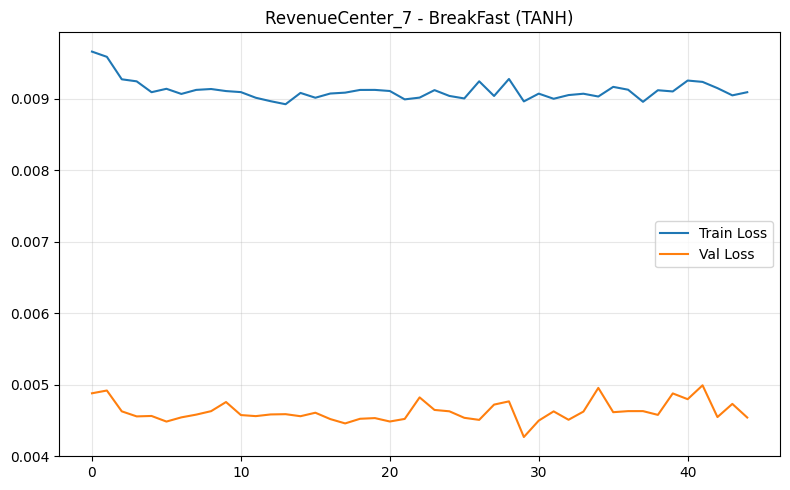

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


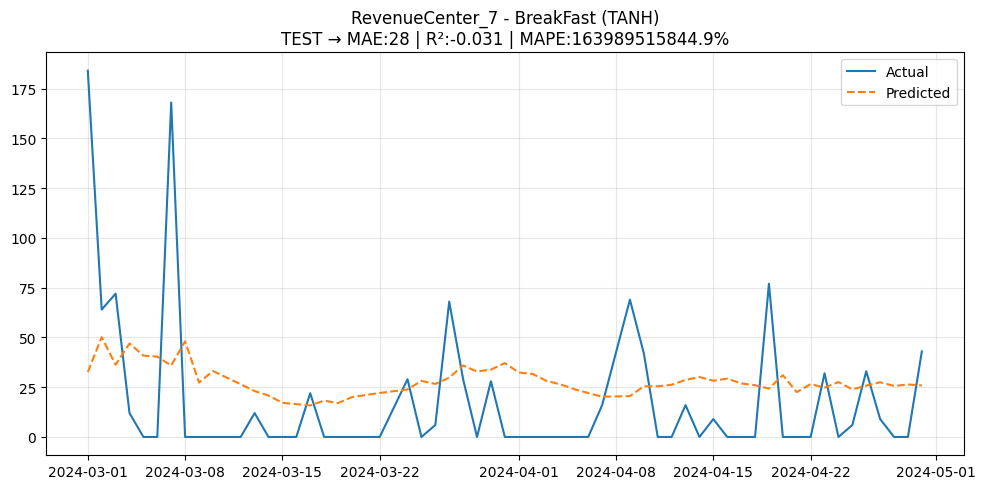

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.0123 - val_loss: 0.0415
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0101 - val_loss: 0.0428
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0102 - val_loss: 0.0413
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0128 - val_loss: 0.0414
Epoch 5/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0111 - val_loss: 0.0407
Epoch 6/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0115 - val_loss: 0.0408
Epoch 7/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0110 - val_loss: 0.0423
Epoch 8/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0138 - val_loss: 0.0417
Epoch 9/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0095 - val_loss: 0.0403
Epoch 10/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0093 - val_loss: 0.0414
Epoch 11/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0116 - val_loss: 0.0412
Epoch 12/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/ste

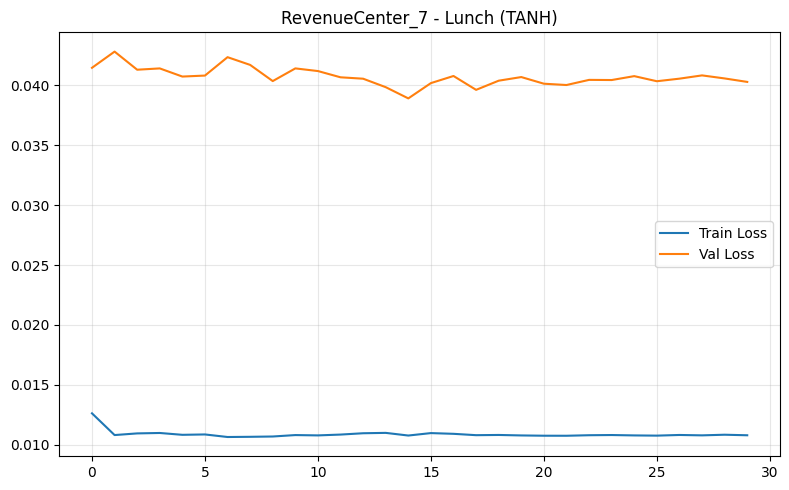

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


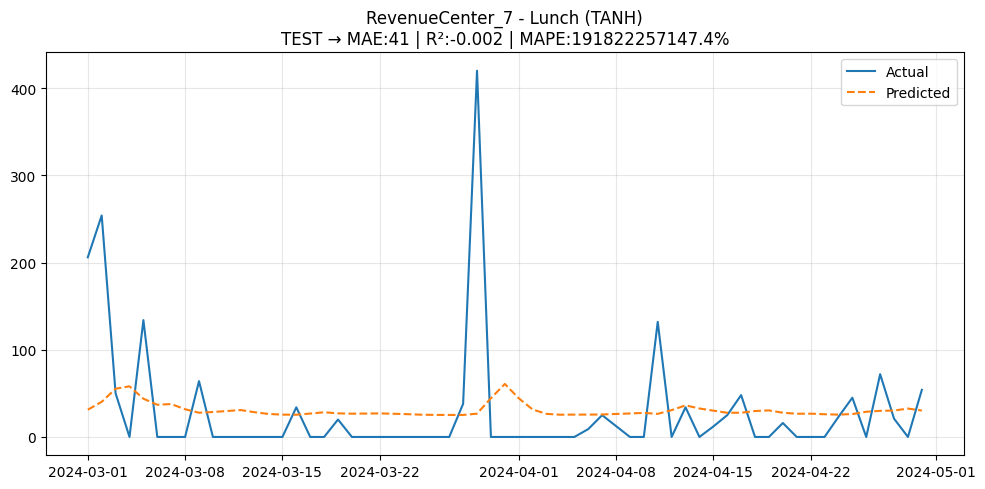

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0261 - val_loss: 0.1085
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0191 - val_loss: 0.0707
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0227 - val_loss: 0.0780
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0204 - val_loss: 0.0807
Epoch 5/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0177 - val_loss: 0.0842
Epoch 6/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0155 - val_loss: 0.0859
Epoch 7/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0159 - val_loss: 0.0849
Epoch 8/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0167 - val_loss: 0.0825
Epoch 9/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0175 - val_loss: 0.0832
Epoch 10/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0176 - val_loss: 0.0818
Epoch 11/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0191 - val_loss: 0.0828
Epoch 12/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step

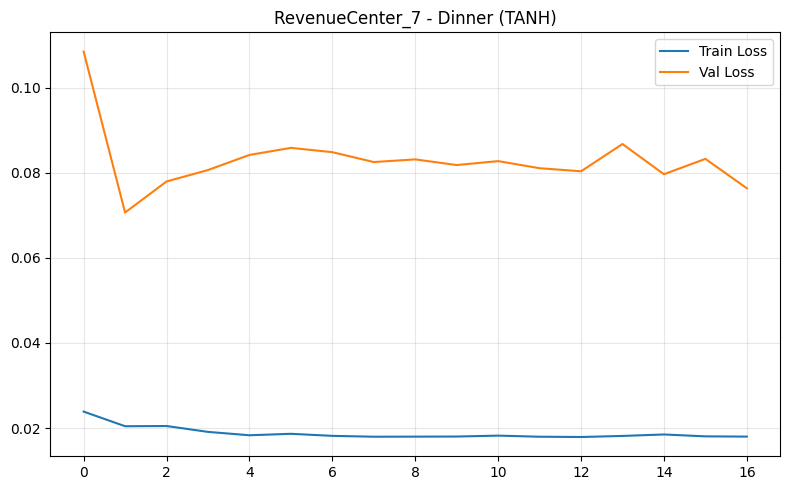

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


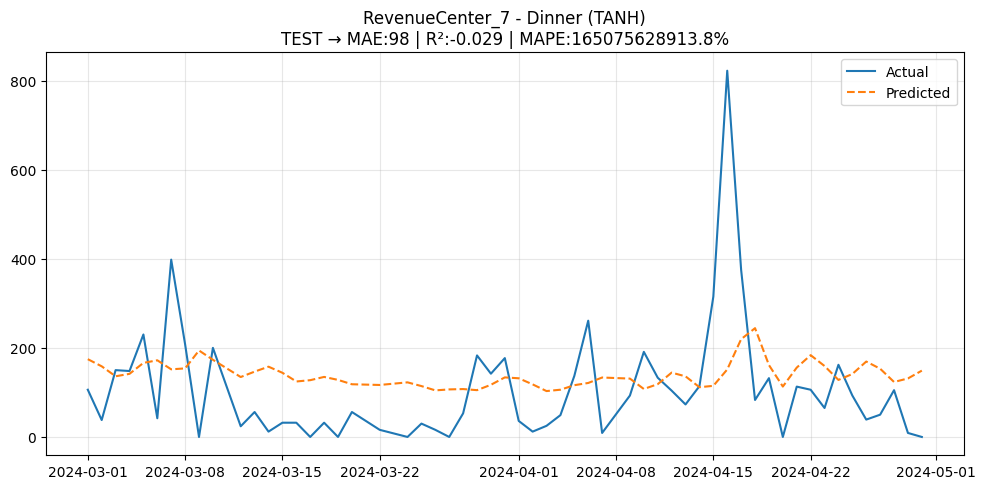

Saved: /content/RevenueCenter_7

Processing: RevenueCenter_2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0265 - val_loss: 0.0366
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0208 - val_loss: 0.0343
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0161 - val_loss: 0.0252
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0185 - val_loss: 0.0332
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0148 - val_loss: 0.0330
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0186 - val_loss: 0.0310
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0154 - val_loss: 0.0281
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0149 - val_loss: 0.0293
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0181 - val_loss: 0.0488
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0269 - val_loss: 0.0407
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0171 - val_loss: 0.0287
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step

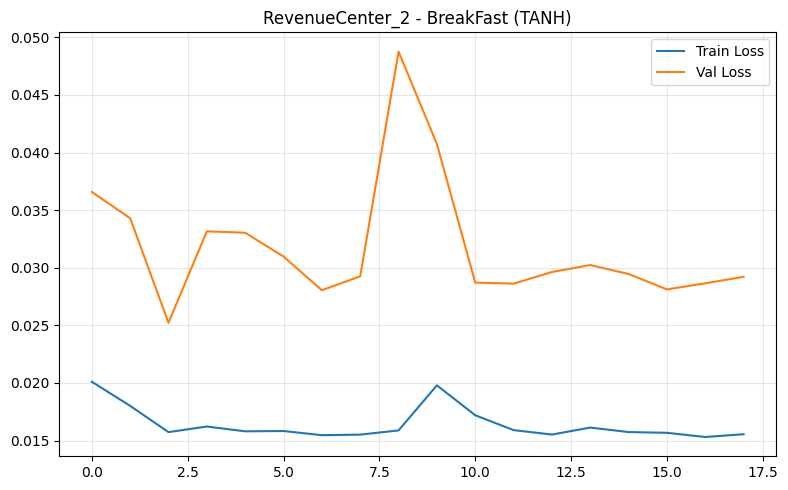

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


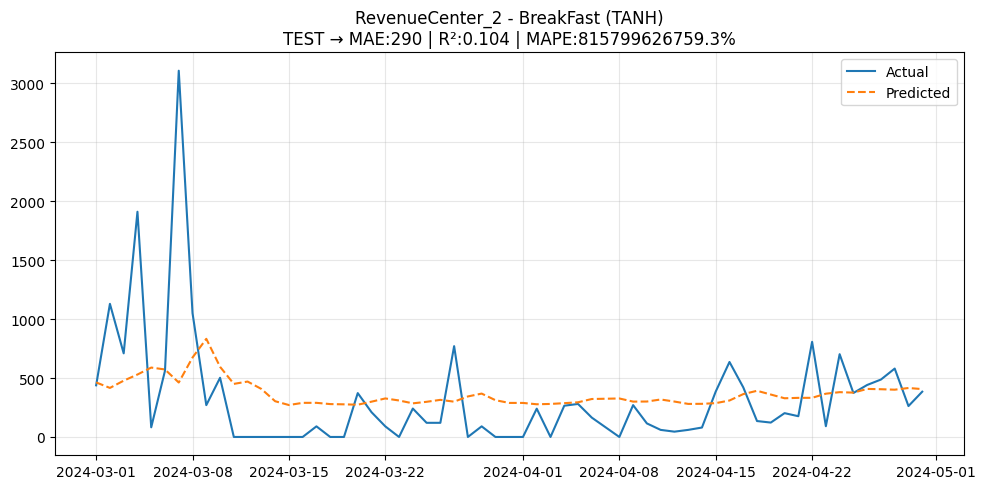

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0376 - val_loss: 0.0984
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0224 - val_loss: 0.0633
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0172 - val_loss: 0.0687
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0165 - val_loss: 0.0639
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0143 - val_loss: 0.0581
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0182 - val_loss: 0.0755
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0151 - val_loss: 0.0683
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0154 - val_loss: 0.0657
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0168 - val_loss: 0.0692
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0140 - val_loss: 0.0588
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0153 - val_loss: 0.0729
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step

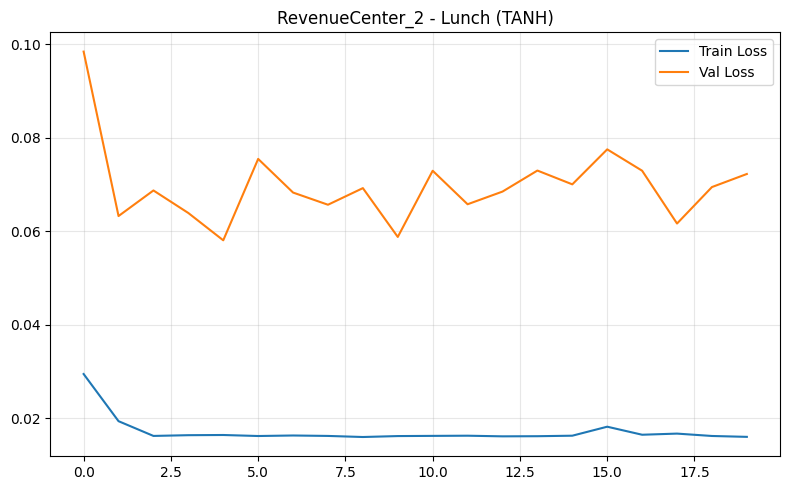

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


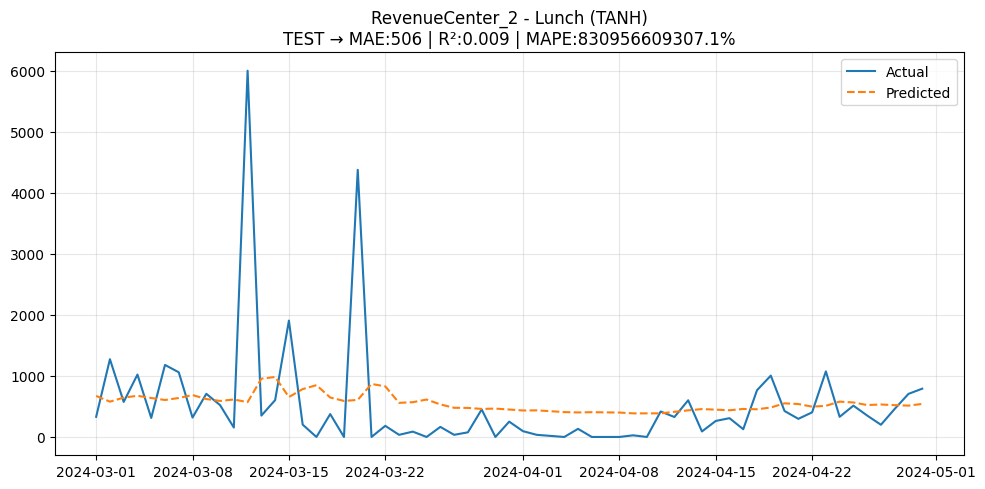

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0039 - val_loss: 0.0312
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0025 - val_loss: 0.0312
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0022 - val_loss: 0.0286
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0018 - val_loss: 0.0279
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0019 - val_loss: 0.0306
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0021 - val_loss: 0.0294
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0020 - val_loss: 0.0284
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0020 - val_loss: 0.0299
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0019 - val_loss: 0.0282
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0018 - val_loss: 0.0293
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0023 - val_loss: 0.0286
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step

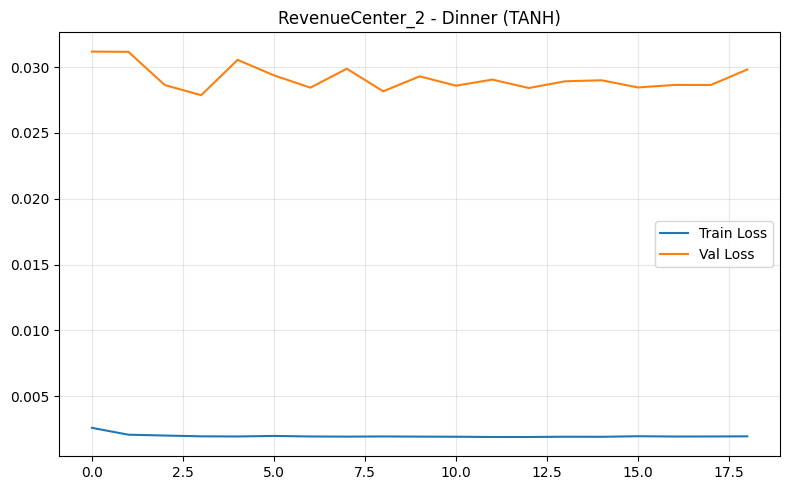

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


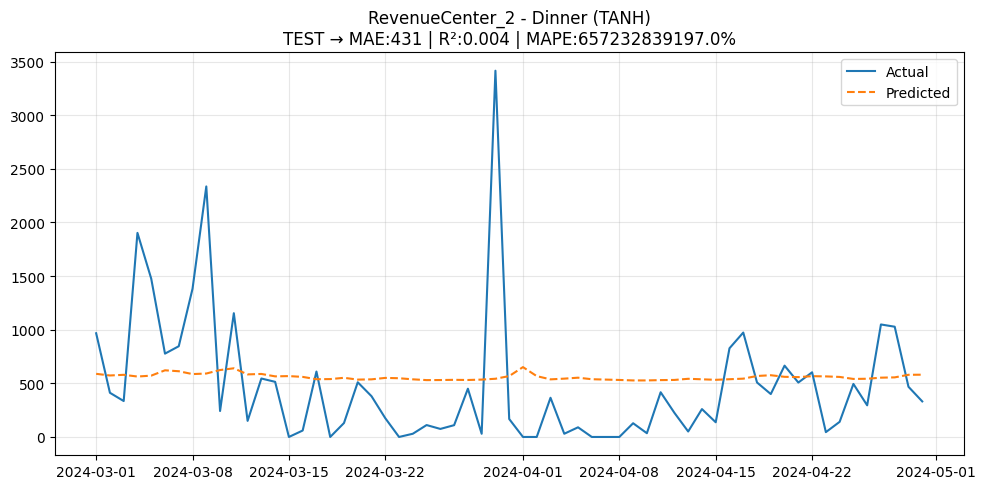

Saved: /content/RevenueCenter_2

Processing: RevenueCenter_1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0091 - val_loss: 0.0266
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0058 - val_loss: 0.0399
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0050 - val_loss: 0.0358
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0070 - val_loss: 0.0331
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0051 - val_loss: 0.0260
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0057 - val_loss: 0.0297
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0041 - val_loss: 0.0312
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0052 - val_loss: 0.0432
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0070 - val_loss: 0.0360
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0045 - val_loss: 0.0327
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0052 - val_loss: 0.0370
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step

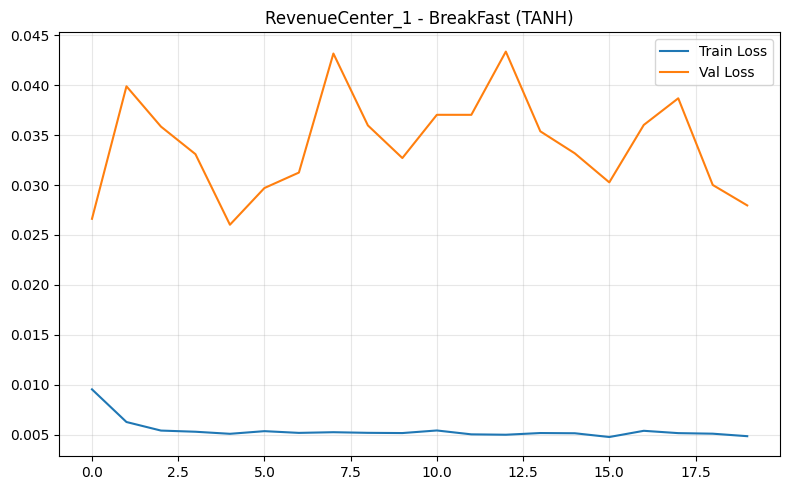

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


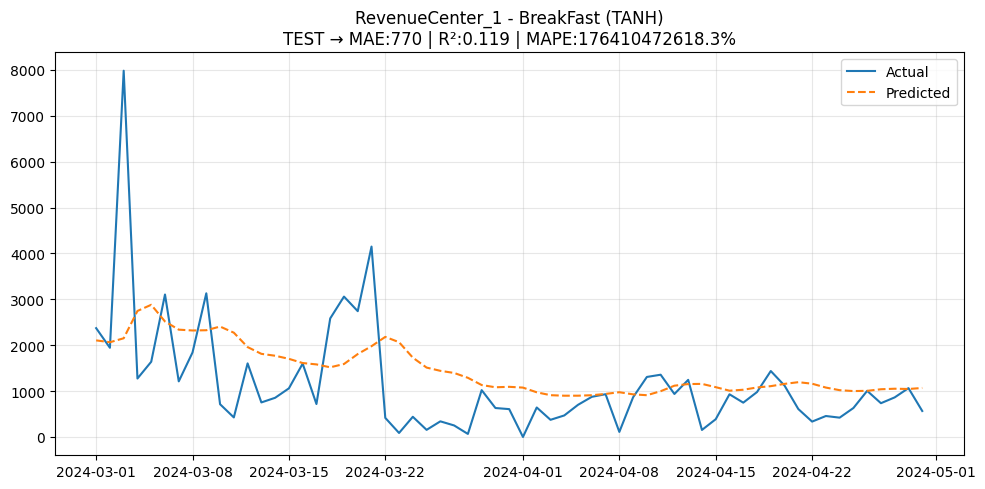

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0261 - val_loss: 0.1107
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0096 - val_loss: 0.0563
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0146 - val_loss: 0.0570
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0169 - val_loss: 0.1015
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0160 - val_loss: 0.0597
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0120 - val_loss: 0.0780
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0115 - val_loss: 0.0738
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0117 - val_loss: 0.0748
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0113 - val_loss: 0.0828
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0167 - val_loss: 0.0715
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0100 - val_loss: 0.0656
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step

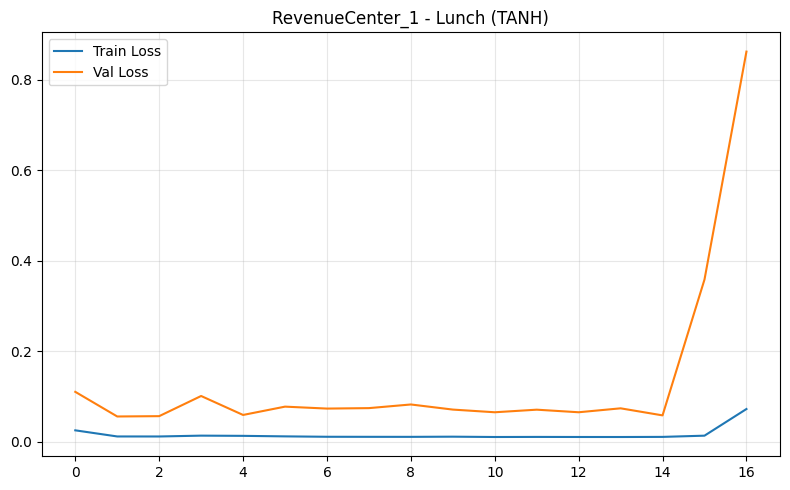

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


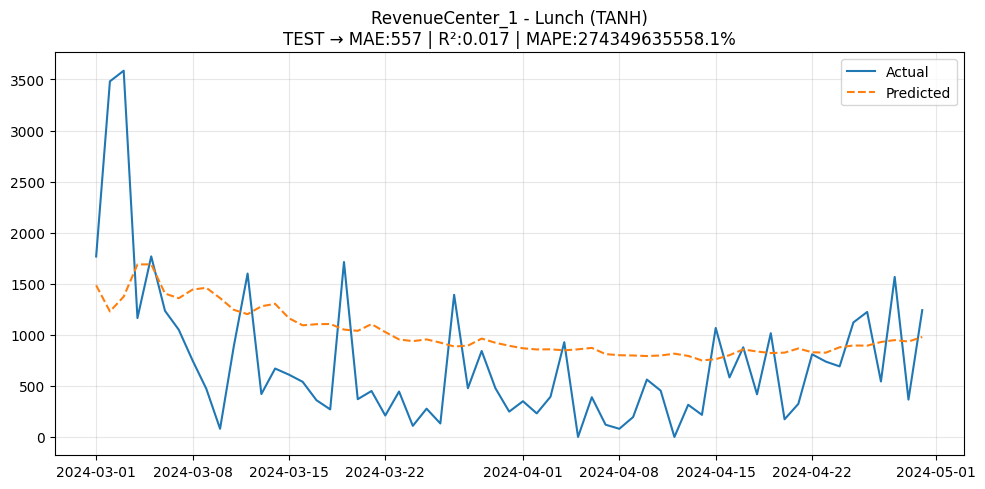

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0429 - val_loss: 0.0852
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0164 - val_loss: 0.0250
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0198 - val_loss: 0.0432
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0140 - val_loss: 0.0322
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0137 - val_loss: 0.0346
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0136 - val_loss: 0.0428
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0111 - val_loss: 0.0349
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0104 - val_loss: 0.0397
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0126 - val_loss: 0.0323
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0129 - val_loss: 0.0333
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0115 - val_loss: 0.0393
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step

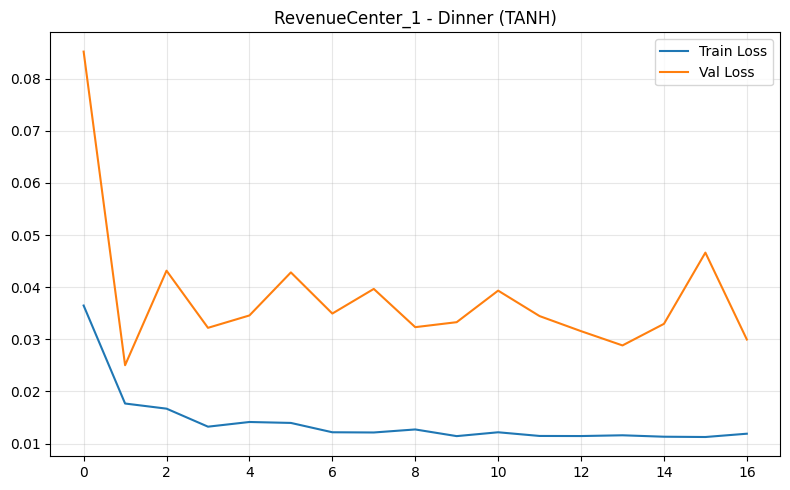

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


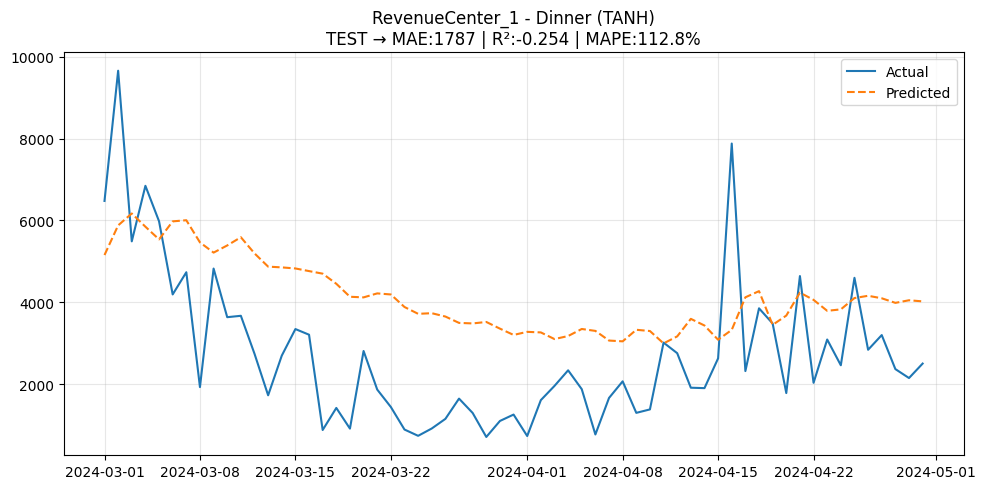

Saved: /content/RevenueCenter_1

Processing: RevenueCenter_6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0316 - val_loss: 0.0514
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0238 - val_loss: 0.0500
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0252 - val_loss: 0.0522
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0237 - val_loss: 0.0522
Epoch 5/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0214 - val_loss: 0.0512
Epoch 6/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0251 - val_loss: 0.0508
Epoch 7/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0286 - val_loss: 0.0511
Epoch 8/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0245 - val_loss: 0.0492
Epoch 9/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0167 - val_loss: 0.0500
Epoch 10/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0205 - val_loss: 0.0499
Epoch 11/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0229 - val_loss: 0.0493
Epoch 12/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step

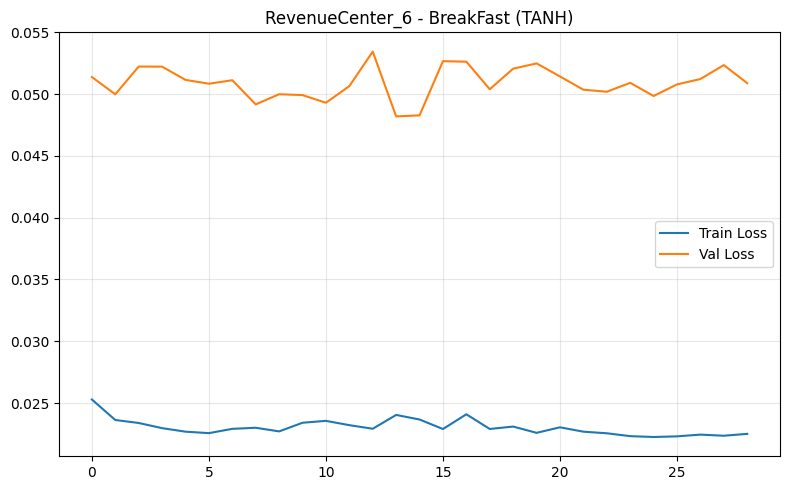

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


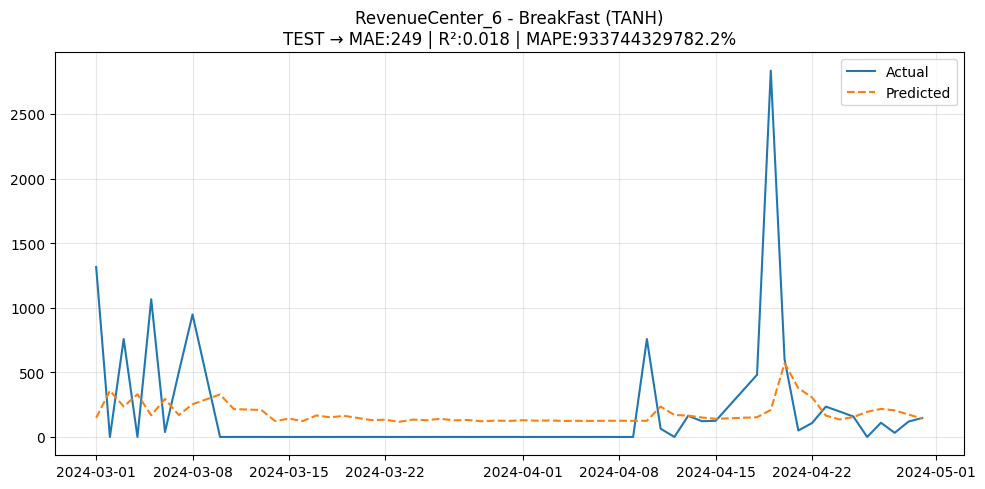

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - loss: 0.0163 - val_loss: 0.0280
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0107 - val_loss: 0.0251
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0081 - val_loss: 0.0207
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0081 - val_loss: 0.0230
Epoch 5/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0118 - val_loss: 0.0229
Epoch 6/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0130 - val_loss: 0.0238
Epoch 7/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0101 - val_loss: 0.0209
Epoch 8/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0109 - val_loss: 0.0208
Epoch 9/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0107 - val_loss: 0.0192
Epoch 10/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0095 - val_loss: 0.0193
Epoch 11/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0091 - val_loss: 0.0196
Epoch 12/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/ste

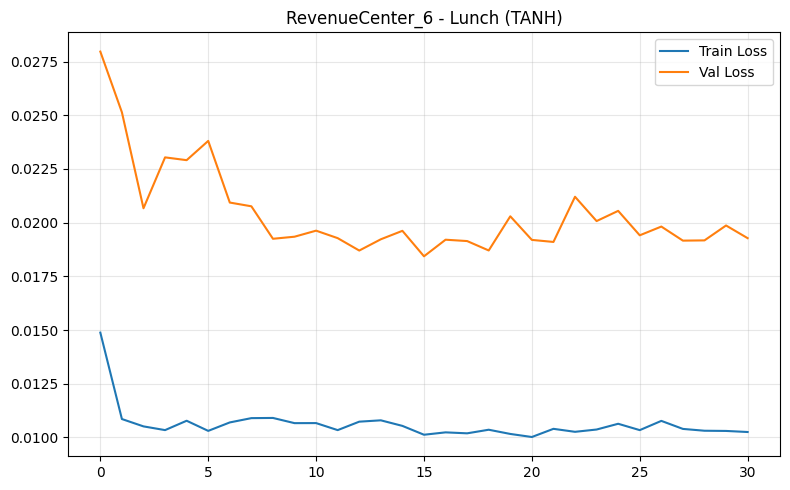

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


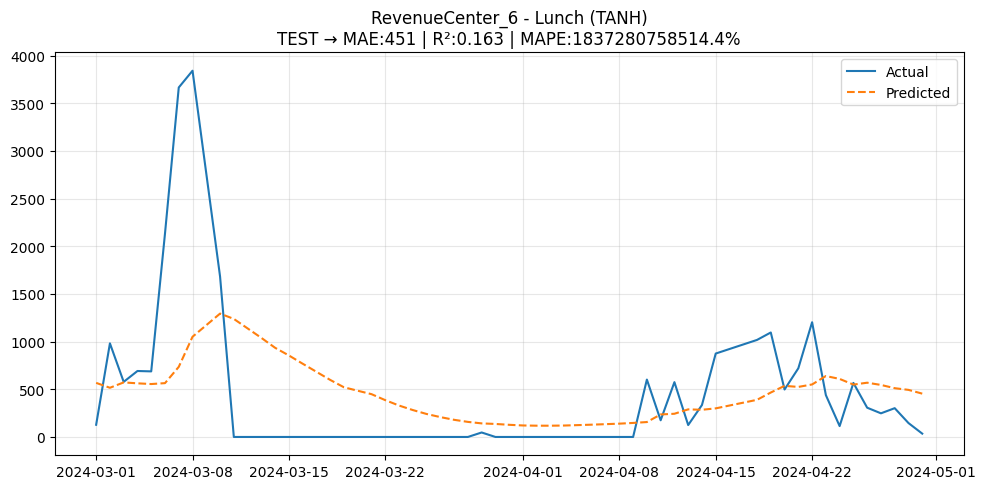

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 0.0027 - val_loss: 0.0247
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0019 - val_loss: 0.0248
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0016 - val_loss: 0.0247
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0017 - val_loss: 0.0246
Epoch 5/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0023 - val_loss: 0.0249
Epoch 6/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0049 - val_loss: 0.0250
Epoch 7/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0040 - val_loss: 0.0249
Epoch 8/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0034 - val_loss: 0.0249
Epoch 9/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0035 - val_loss: 0.0249
Epoch 10/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0017 - val_loss: 0.0249
Epoch 11/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0025 - val_loss: 0.0248
Epoch 12/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/ste

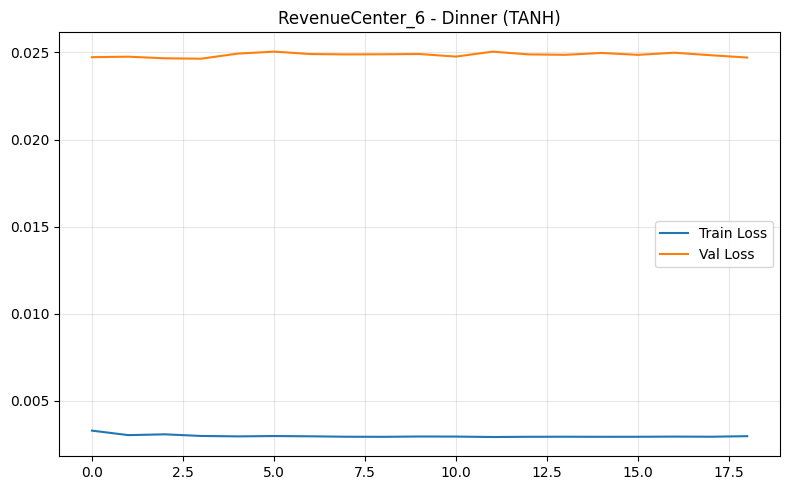

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


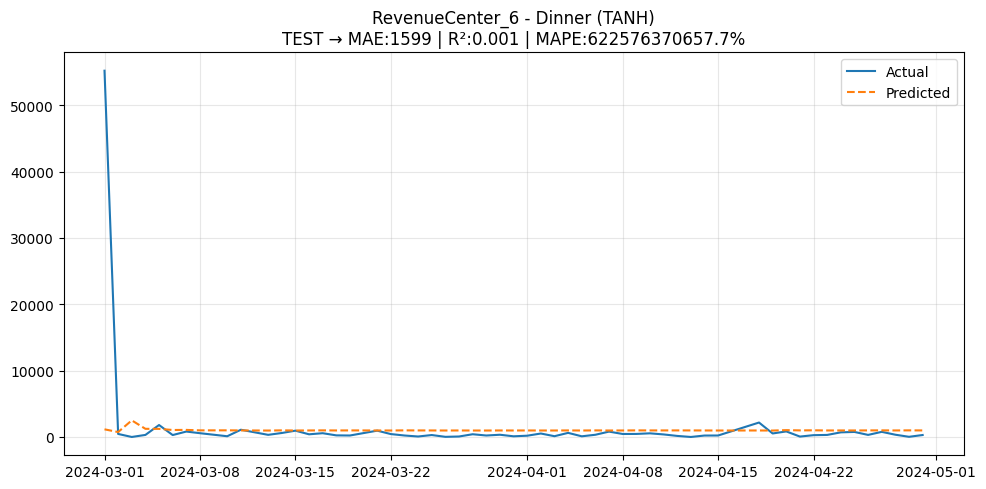

Saved: /content/RevenueCenter_6

Processing: RevenueCenter_4
Skipping RevenueCenter_4 - BreakFast (constant values)
Skipping RevenueCenter_4 - Lunch (constant values)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 0.0036 - val_loss: 1.8593e-05
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0017 - val_loss: 2.5074e-05
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0055 - val_loss: 2.2837e-06
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0034 - val_loss: 2.5052e-05
Epoch 5/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0022 - val_loss: 1.3814e-05
Epoch 6/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 7.4981e-04 - val_loss: 4.0726e-06
Epoch 7/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 4.8887e-04 - val_loss: 4.6808e-06
Epoch 8/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0033 - val_loss: 1.7942e-05
Epoch 9/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0081 - val_loss: 4.9134e-06
Epoch 10/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0042 - val_loss: 1.0969e-05
Epoch 11/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0022 - val_loss: 2.0229e-05


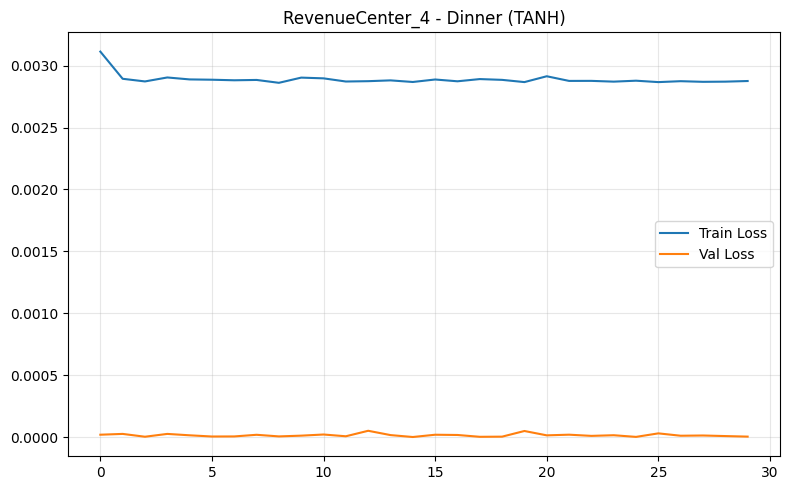

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


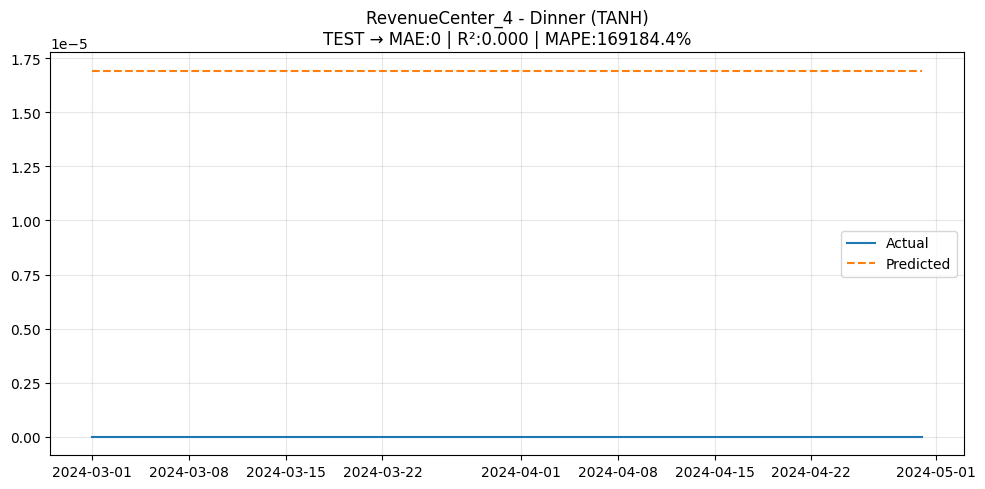

Saved: /content/RevenueCenter_4

Processing: RevenueCenter_8


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0082 - val_loss: 0.0023
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0052 - val_loss: 0.0026
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0061 - val_loss: 0.0025
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0088 - val_loss: 0.0023
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0082 - val_loss: 0.0024
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0106 - val_loss: 0.0024
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0117 - val_loss: 0.0024
Epoch 8/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0067 - val_loss: 0.0024
Epoch 9/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0076 - val_loss: 0.0025
Epoch 10/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0103 - val_loss: 0.0024
Epoch 11/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0064 - val_loss: 0.0025
Epoch 12/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step

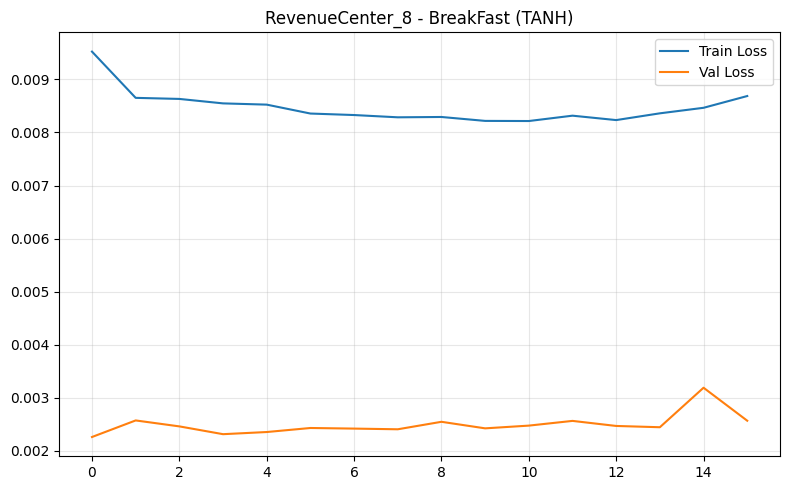

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


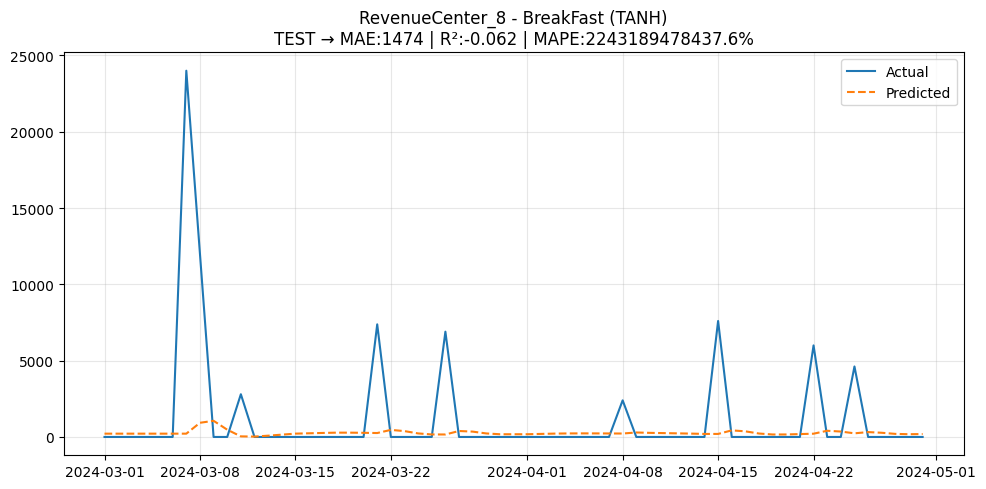

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 0.0227 - val_loss: 0.1049
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0154 - val_loss: 0.1041
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0144 - val_loss: 0.0935
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0159 - val_loss: 0.0980
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0131 - val_loss: 0.0920
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0149 - val_loss: 0.0979
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0142 - val_loss: 0.0932
Epoch 8/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0160 - val_loss: 0.0950
Epoch 9/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0109 - val_loss: 0.0949
Epoch 10/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0150 - val_loss: 0.0965
Epoch 11/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0152 - val_loss: 0.0933
Epoch 12/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step

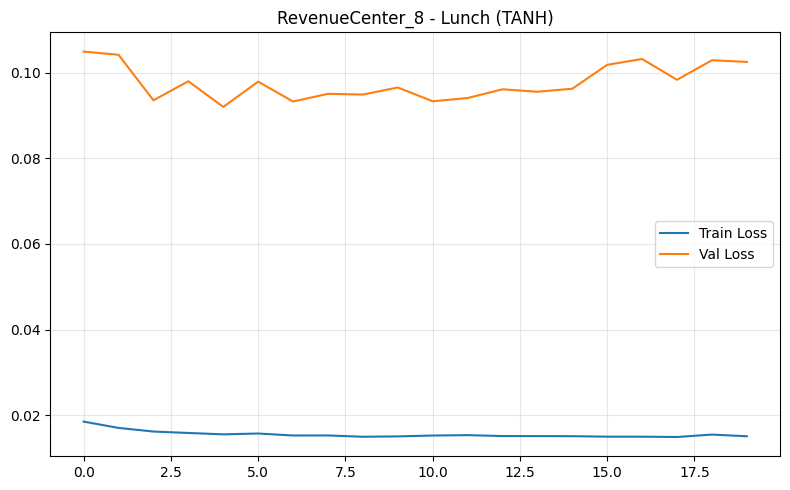

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


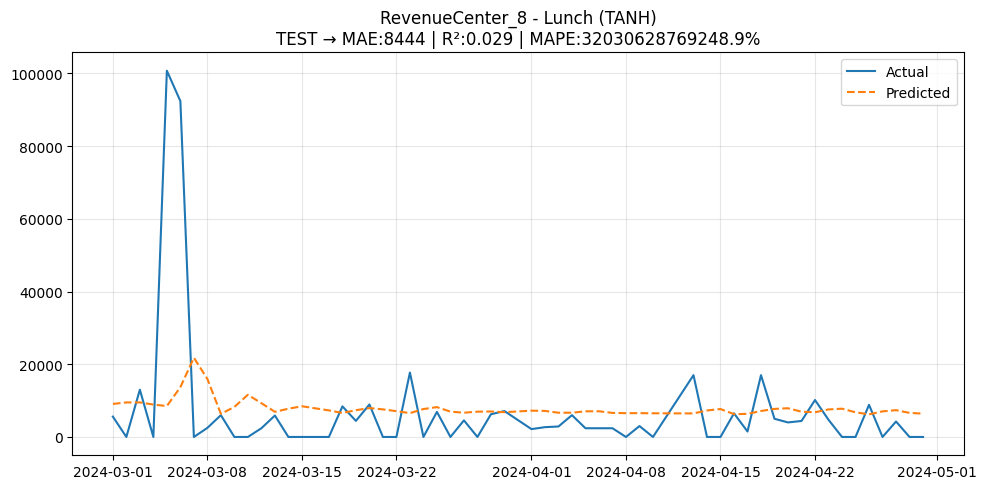

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 0.0227 - val_loss: 0.0734
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0185 - val_loss: 0.0675
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0130 - val_loss: 0.0480
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0161 - val_loss: 0.0638
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0116 - val_loss: 0.0495
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0134 - val_loss: 0.0605
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0116 - val_loss: 0.0558
Epoch 8/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0113 - val_loss: 0.0590
Epoch 9/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0102 - val_loss: 0.0577
Epoch 10/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0108 - val_loss: 0.0554
Epoch 11/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0123 - val_loss: 0.0558
Epoch 12/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step

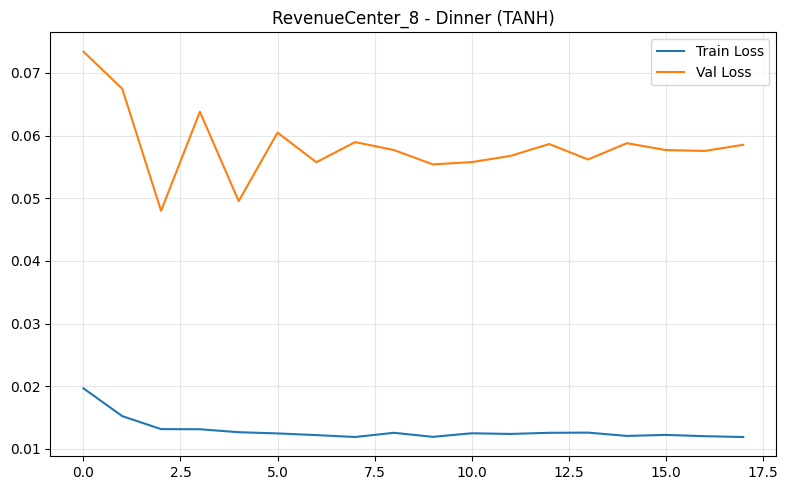

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


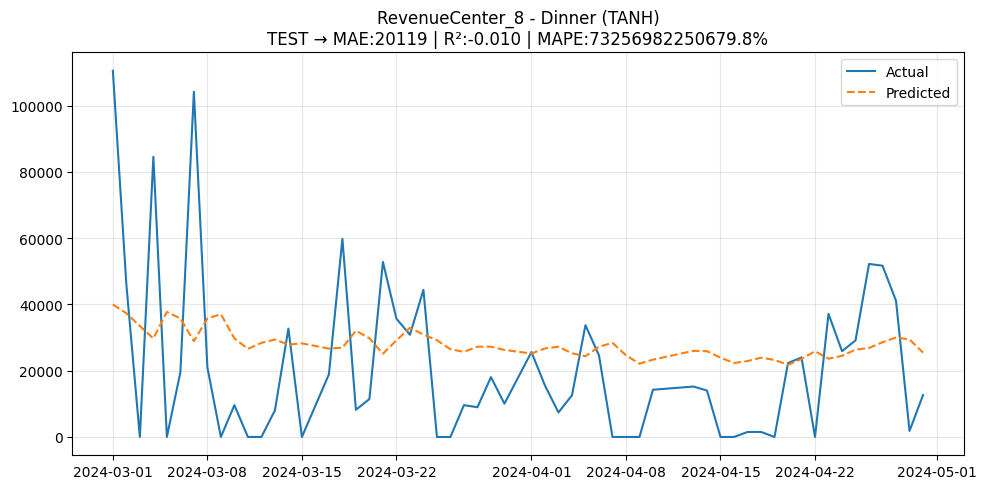

Saved: /content/RevenueCenter_8

Processing: RevenueCenter_3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0409 - val_loss: 0.0512
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0264 - val_loss: 0.0357
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0241 - val_loss: 0.0378
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0258 - val_loss: 0.0367
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0242 - val_loss: 0.0361
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0262 - val_loss: 0.0412
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0209 - val_loss: 0.0357
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0238 - val_loss: 0.0405
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0225 - val_loss: 0.0386
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0225 - val_loss: 0.0363
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0199 - val_loss: 0.0395
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step

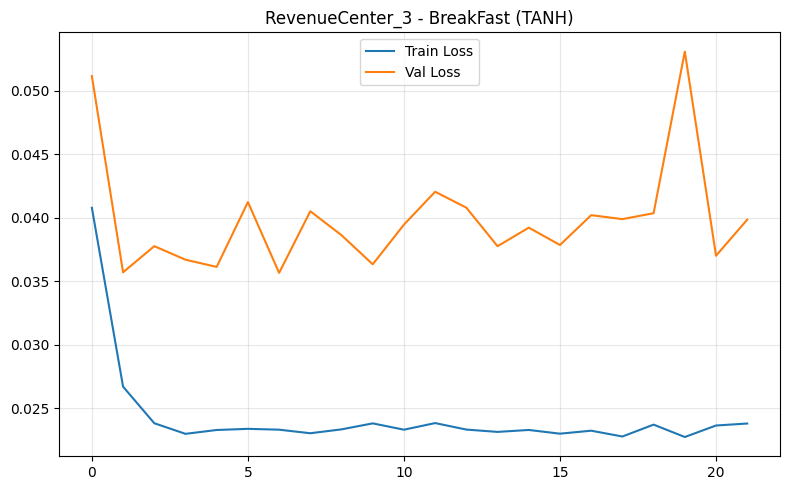

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


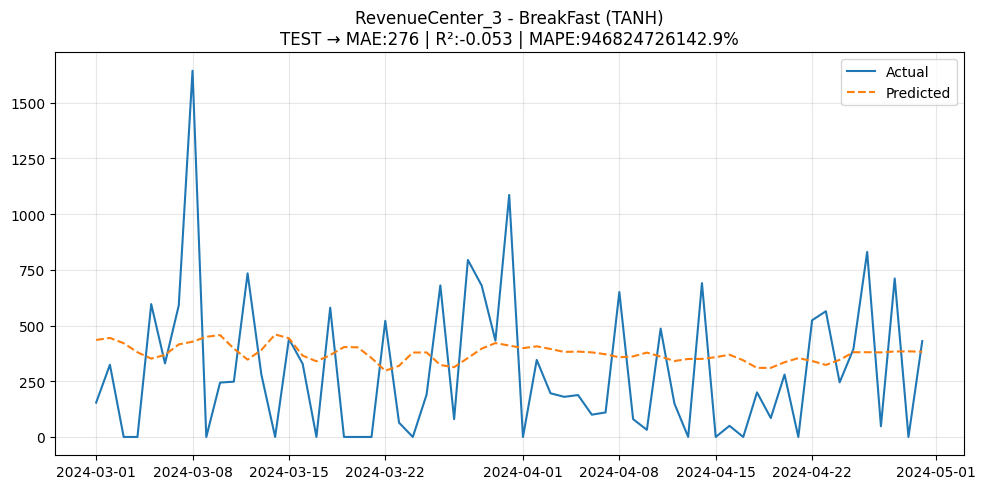

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0214 - val_loss: 0.0432
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0112 - val_loss: 0.0507
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0086 - val_loss: 0.0475
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0101 - val_loss: 0.0484
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0101 - val_loss: 0.0470
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0104 - val_loss: 0.0531
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0115 - val_loss: 0.0684
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0089 - val_loss: 0.0569
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0118 - val_loss: 0.0557
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0095 - val_loss: 0.0573
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0091 - val_loss: 0.0613
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step

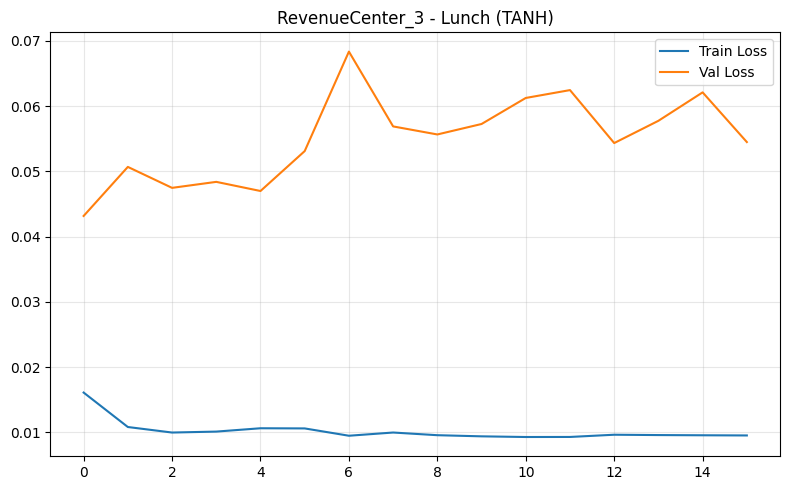

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


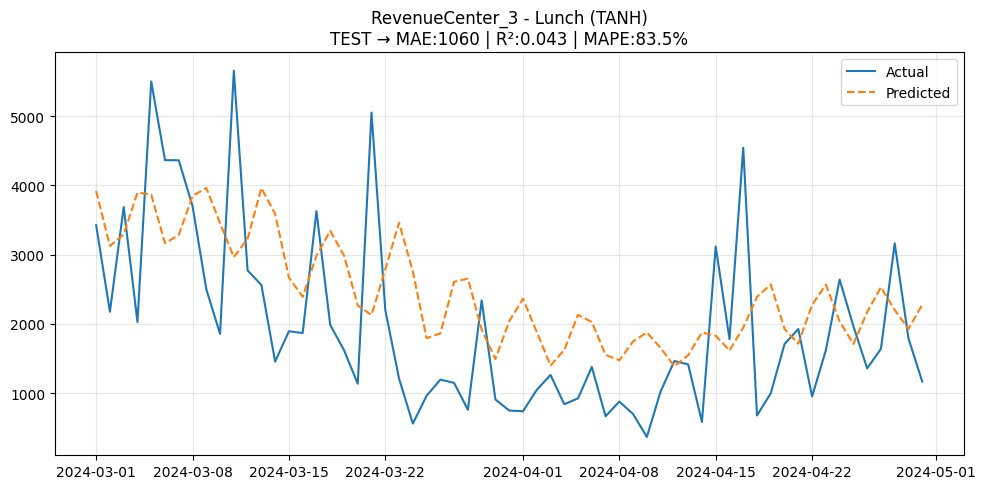

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0506 - val_loss: 0.2043
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0332 - val_loss: 0.0237
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0346 - val_loss: 0.1391
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0179 - val_loss: 0.0700
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0147 - val_loss: 0.0928
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0126 - val_loss: 0.1260
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0106 - val_loss: 0.1071
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0110 - val_loss: 0.0877
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0131 - val_loss: 0.1224
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0119 - val_loss: 0.0796
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0100 - val_loss: 0.0991
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step

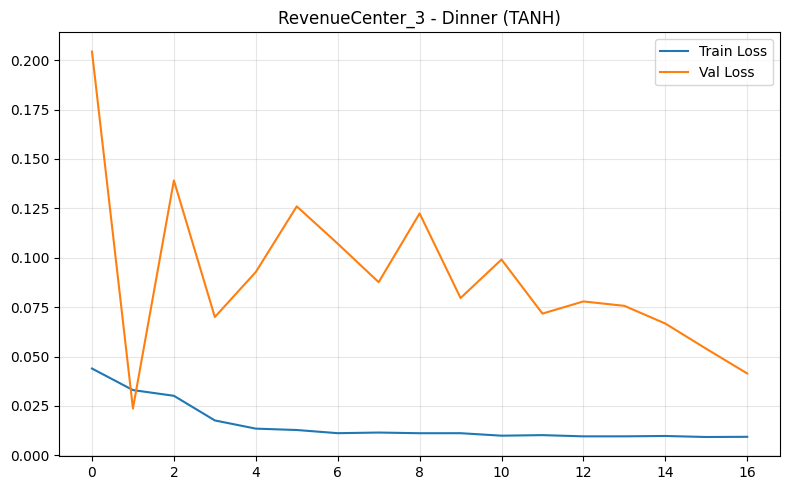

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


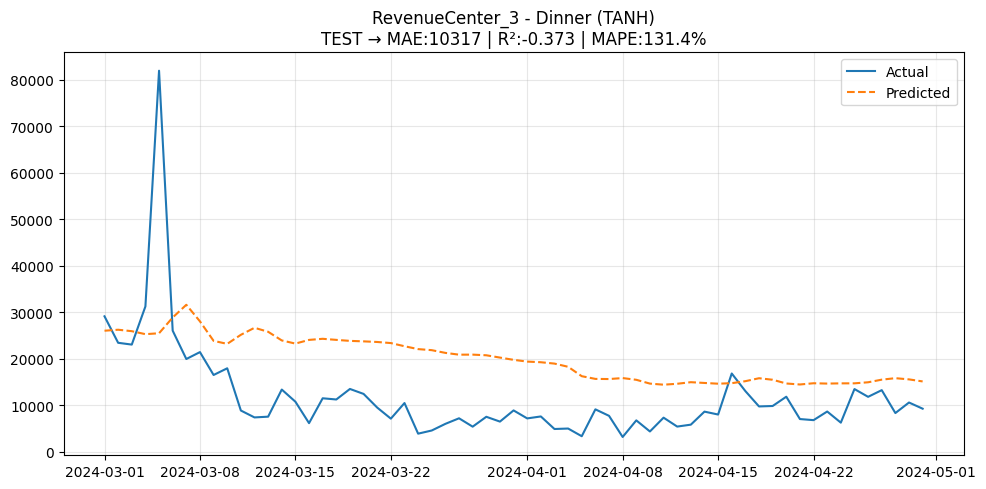

Saved: /content/RevenueCenter_3

Processing: RevenueCenter_9


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 0.0090 - val_loss: 0.0712
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0136 - val_loss: 0.0809
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0094 - val_loss: 0.0744
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0087 - val_loss: 0.0664
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0091 - val_loss: 0.0829
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0084 - val_loss: 0.0750
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0086 - val_loss: 0.0696
Epoch 8/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0073 - val_loss: 0.0726
Epoch 9/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0075 - val_loss: 0.0680
Epoch 10/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0078 - val_loss: 0.0687
Epoch 11/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0096 - val_loss: 0.0690
Epoch 12/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step

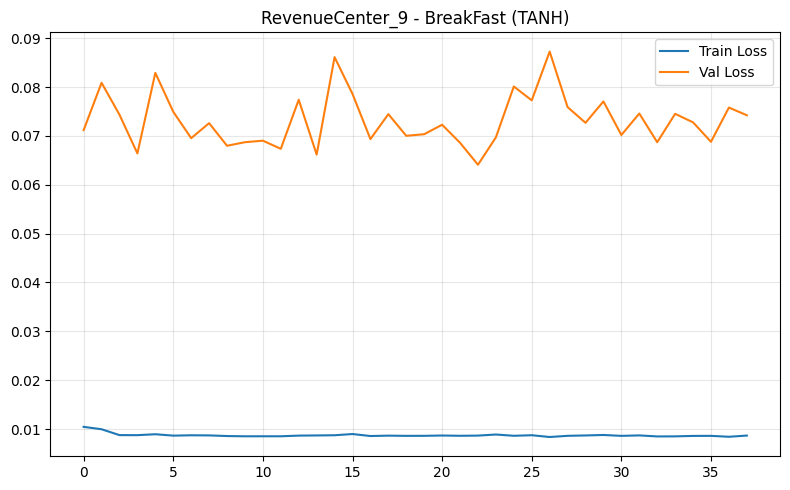

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


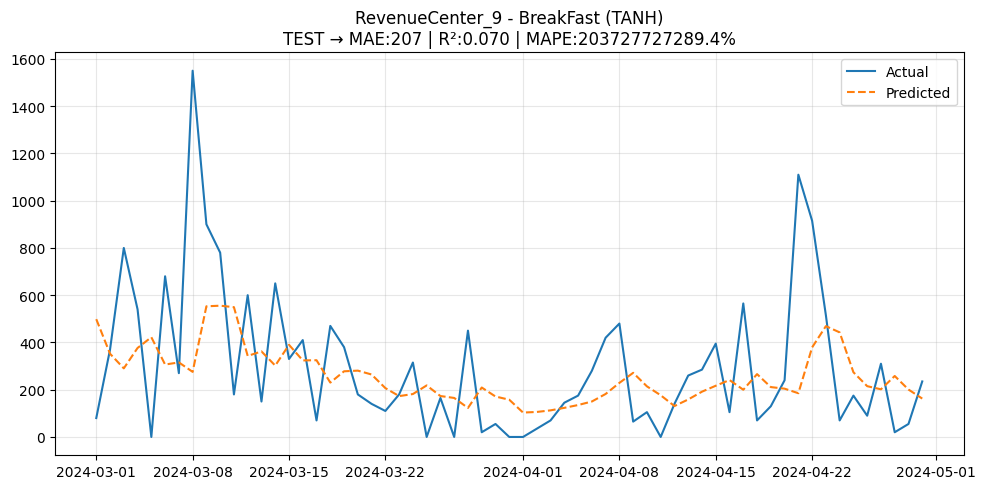

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0558 - val_loss: 0.0669
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0486 - val_loss: 0.0675
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0398 - val_loss: 0.0525
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.0289 - val_loss: 0.0440
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0337 - val_loss: 0.0437
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0349 - val_loss: 0.0495
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0324 - val_loss: 0.0434
Epoch 8/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0299 - val_loss: 0.0471
Epoch 9/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0358 - val_loss: 0.0487
Epoch 10/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 0.0283 - val_loss: 0.0428
Epoch 11/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0279 - val_loss: 0.0455
Epoch 12/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step

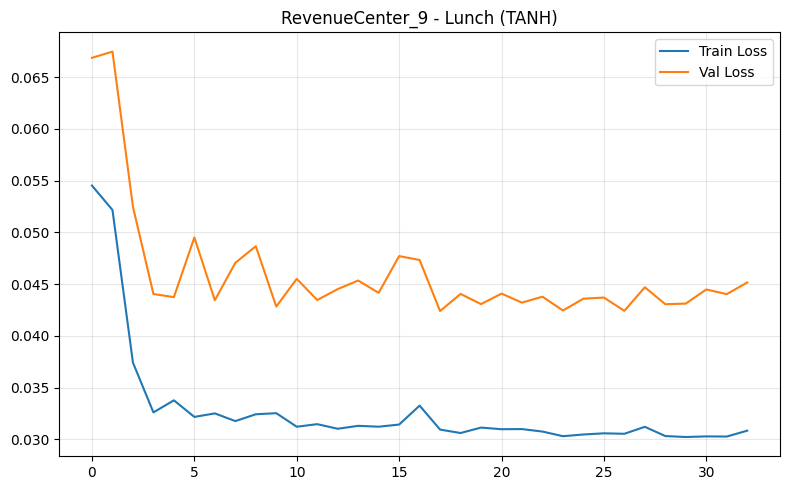

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


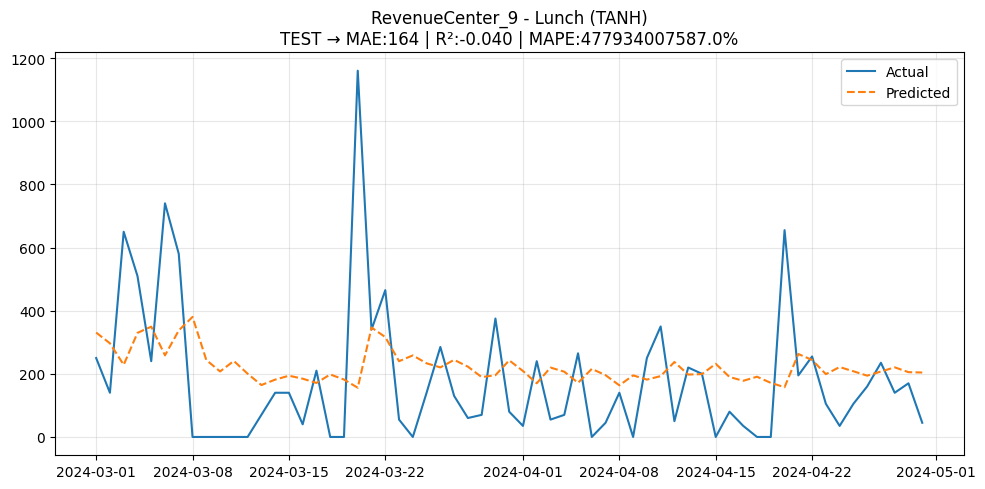

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 269ms/step - loss: 0.0210 - val_loss: 0.0136
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0193 - val_loss: 0.0138
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0321 - val_loss: 0.0139
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0220 - val_loss: 0.0149
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0196 - val_loss: 0.0145
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0188 - val_loss: 0.0149
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0204 - val_loss: 0.0149
Epoch 8/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0167 - val_loss: 0.0154
Epoch 9/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0186 - val_loss: 0.0161
Epoch 10/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0183 - val_loss: 0.0150
Epoch 11/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0167 - val_loss: 0.0157
Epoch 12/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/ste

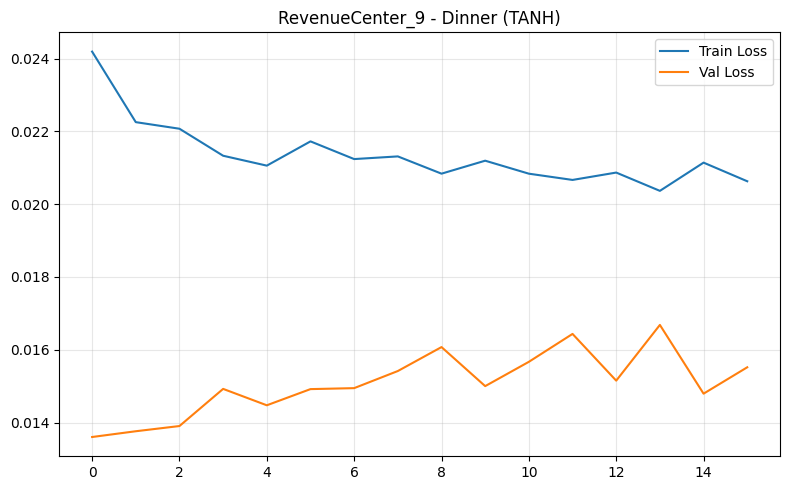

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


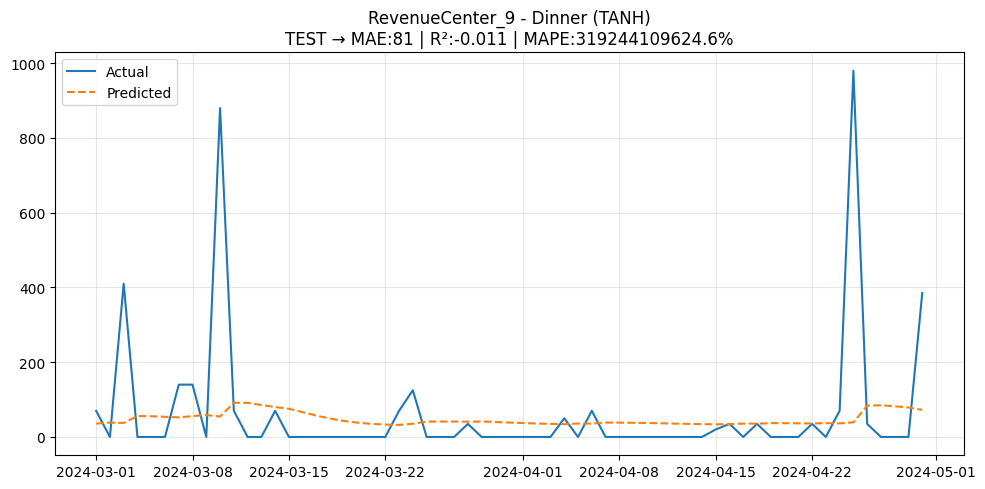

Saved: /content/RevenueCenter_9

ALL CENTERS COMPLETED — TANH MODEL


In [16]:
for file in files:

    center_name = os.path.basename(file).replace(".xlsx", "")
    print("\nProcessing:", center_name)

    center_path = os.path.join(output_folder, center_name)
    os.makedirs(center_path, exist_ok=True)

    df = pd.read_excel(file)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    split_date = df["Date"].max() - pd.DateOffset(months=2)
    meals = ["BreakFast", "Lunch", "Dinner"]

    for meal in meals:

        temp_df = df[["Date", meal]].copy()
        temp_df.rename(columns={meal: "y"}, inplace=True)

        train_df = temp_df[temp_df["Date"] <= split_date]
        test_df  = temp_df[temp_df["Date"] > split_date]

        if train_df["y"].nunique() <= 1:
            print(f"Skipping {center_name} - {meal} (constant values)")
            continue

        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train_df[["y"]])
        test_scaled  = scaler.transform(test_df[["y"]])

        WINDOW = 30
        X_train, y_train = create_sequences(train_scaled, WINDOW)
        combined = np.vstack([train_scaled[-WINDOW:], test_scaled])
        X_test, y_test = create_sequences(combined, WINDOW)

        X_train = X_train.reshape(-1, WINDOW, 1)
        X_test  = X_test.reshape(-1, WINDOW, 1)

        # =========================
        # MODEL — TANH
        # =========================
        model = Sequential([
            LSTM(
                2048,
                activation="tanh",
                recurrent_activation="sigmoid",
                input_shape=(WINDOW, 1)
            ),
            Dense(1)
        ])

        model.compile(optimizer="adam", loss="mse")

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        )

        history = model.fit(
            X_train, y_train,
            epochs=150,
            batch_size=32,
            validation_split=0.1,
            callbacks=[early_stop],
            verbose=1
        )

        # =========================
        # LOSS PLOT
        # =========================
        plt.figure(figsize=(8,5))
        plt.plot(history.history["loss"], label="Train Loss")
        plt.plot(history.history["val_loss"], label="Val Loss")
        plt.title(f"{center_name} - {meal} (TANH)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(center_path, f"{meal}_loss_tanh.png"), dpi=300)
        plt.show()
        plt.close()

        # =========================
        # PREDICTIONS
        # =========================
        y_train_pred = scaler.inverse_transform(model.predict(X_train))
        y_test_pred  = scaler.inverse_transform(model.predict(X_test))
        y_train_true = scaler.inverse_transform(y_train.reshape(-1,1))
        y_test_true  = scaler.inverse_transform(y_test.reshape(-1,1))

        train_mae  = mean_absolute_error(y_train_true, y_train_pred)
        train_r2   = r2_score(y_train_true, y_train_pred)
        train_mape = mape(y_train_true, y_train_pred)

        test_mae  = mean_absolute_error(y_test_true, y_test_pred)
        test_r2   = r2_score(y_test_true, y_test_pred)
        test_mape = mape(y_test_true, y_test_pred)

        plt.figure(figsize=(10,5))
        plt.plot(test_df["Date"], y_test_true, label="Actual")
        plt.plot(test_df["Date"], y_test_pred, "--", label="Predicted")
        plt.title(
            f"{center_name} - {meal} (TANH)\n"
            f"TEST → MAE:{test_mae:.0f} | R²:{test_r2:.3f} | MAPE:{test_mape:.1f}%"
        )
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(center_path, f"{meal}_pred_tanh.png"), dpi=300)
        plt.show()
        plt.close()

    print("Saved:", center_path)

print("\nALL CENTERS COMPLETED — TANH MODEL")

In [ ]:
y_min = y_train.min()
y_max = y_train.max()

print("Target range:", y_min, "to", y_max)
print("Range width:", y_max - y_min)

Target range: 0.0 to 37870.0
Range width: 37870.0
